In [1]:
import pywt
import numpy as np
import pandas as pd
import os

In [2]:
os.chdir('..')

In [5]:
df = pd.read_csv('data/BTCUSD_2023_2024.csv', index_col='Gmt time')
# df = df[-4050:]

In [6]:
close = df['Close']

In [7]:
close.index

Index(['01.01.2023 00:00:00.000', '01.01.2023 00:01:00.000',
       '01.01.2023 00:02:00.000', '01.01.2023 00:03:00.000',
       '01.01.2023 00:04:00.000', '01.01.2023 00:05:00.000',
       '01.01.2023 00:06:00.000', '01.01.2023 00:07:00.000',
       '01.01.2023 00:08:00.000', '01.01.2023 00:09:00.000',
       ...
       '05.11.2024 23:50:00.000', '05.11.2024 23:51:00.000',
       '05.11.2024 23:52:00.000', '05.11.2024 23:53:00.000',
       '05.11.2024 23:54:00.000', '05.11.2024 23:55:00.000',
       '05.11.2024 23:56:00.000', '05.11.2024 23:57:00.000',
       '05.11.2024 23:58:00.000', '05.11.2024 23:59:00.000'],
      dtype='object', name='Gmt time', length=972000)

# V2

In [5]:

import pywt
import numpy as np

# -------------------------------------------------------------------------------------------
# Wavelet denoising
#
# Reference: https://doi.org/10.1002/for.3071
# (the idea of the wavelet denoising and some parameters are taken from this paper)
# -------------------------------------------------------------------------------------------

# Function for padding the data
def pad_data(data, pad_width, mode='edge'):
    return np.pad(data, pad_width, mode=mode)

# Wavelet denoising function with parameterisation for wavelet type and decomposition level
def wavelet_denoising(data, wavelet='db4', level=1):
    # Padding with a width of 100
    padded_data = pad_data(data, pad_width=100, mode='edge')
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(padded_data, wavelet, mode="per", level=level)
    coeff_out = coeff.copy()
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    # Calculate the universal threshold
    uthresh = sigma * np.sqrt(2 * np.log(len(padded_data)))
    # uthresh = [sigma * np.sqrt(2 * np.log(len(padded_data))) / (2 ** (i + 1)) for i in range(level)]
    # Apply soft thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=uthresh, mode='hard') for i in coeff[1:]]
    # coeff[1:] = [pywt.threshold(i, value=thresh, mode='soft') for i, thresh in zip(coeff[1:], uthresh)]
    # Set high-frequency coefficients to zero ]
    coeff[-level] = np.zeros_like(coeff[-level])
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    # Remove the padding
    denoised_data = denoised_data[100:-100]  # Adjust this if necessary

    # Handle edge effects
    if len(denoised_data) > len(data):
        denoised_data = denoised_data[:len(data)]
    elif len(denoised_data) < len(data):
        denoised_data = np.pad(denoised_data, (0, len(data) - len(denoised_data)), 'edge')

    return denoised_data, coeff_out, sigma, uthresh, coeff


In [6]:
denoised_data_1, coeff_out_1, sigma_1, uthresh_1, coeff_1 = wavelet_denoising(close, level=1)
denoised_data_2, coeff_out_2, sigma_2, uthresh_2, coeff_2 = wavelet_denoising(close, level=2)
denoised_data_3, coeff_out_3, sigma_3, uthresh_3, coeff_3 = wavelet_denoising(close, level=3)

In [7]:
STOCK = 'BTC'

In [8]:
import matplotlib.pyplot as plt

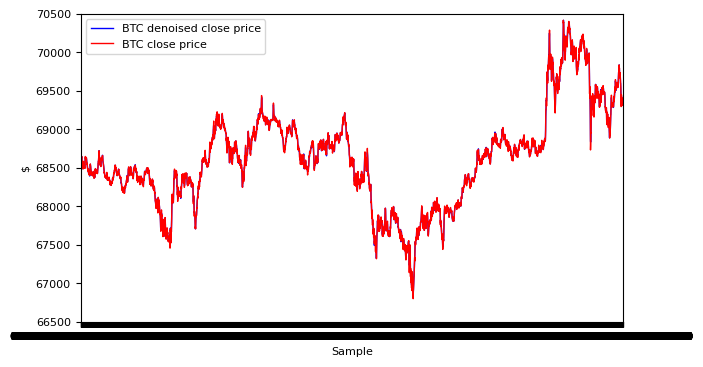

In [9]:
plt.figure(figsize=(7, 4))
# plt.plot(test_rewards_pd['test_rewards'], label='Original Data', color='red')
plt.plot(denoised_data_1, label=f'{STOCK} denoised close price', color='blue', linewidth=1)
plt.plot(close, label=f'{STOCK} close price', color='red', linewidth=1)
# plt.title('Total Rewards')
plt.xlabel('Sample', fontsize = 8)
plt.ylabel('$', fontsize = 8)
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.xlim(0,4050)
plt.ylim(66500,70500)
# plt.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
# plt.savefig(f'denoise/img/db4l1_{STOCK}.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
t = np.linspace(0, 1, 4050)
t.shape

(4050,)

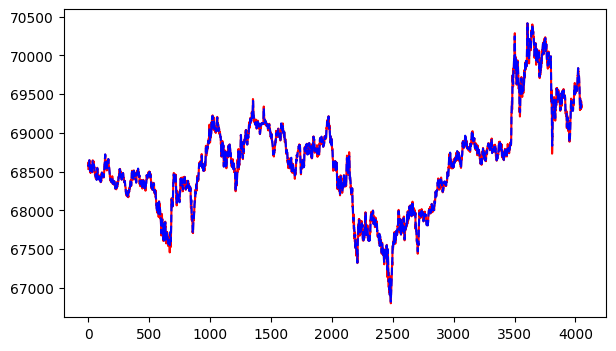

In [11]:
t = np.linspace(0, 4050, 4050)
signal1 = close.to_numpy()
signal2 = denoised_data_1

fig, axs = plt.subplots(1, 1, figsize=(7, 4))

# Main plot
axs.plot(t, signal1, 'r', label=f'{STOCK} close price')
axs.plot(t, signal2, 'b--', label=f'{STOCK} denoised close price')

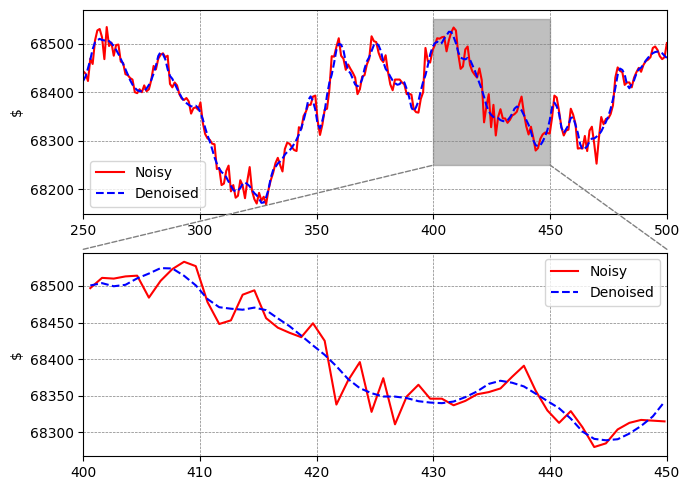

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Polygon

t = np.linspace(250, 500, 250)
signal1 = close[250:500].to_numpy()
# signal2 = denoised_data_1[250:500]
signal3 = denoised_data_2[250:500]

# Define zoom-in region
t_zoom_start, t_zoom_end = 400, 450
mask = (t >= t_zoom_start) & (t <= t_zoom_end)

# Create the figure and axes
fig, axs = plt.subplots(2, 1, figsize=(7, 5))

# Main plot
axs[0].plot(t, signal1, 'r', label=f'Noisy')
# axs[0].plot(t, signal2, 'b--', label=f'Denoised L1')
axs[0].plot(t, signal3, 'b--', label=f'Denoised' )
axs[0].set_ylabel("$")
axs[0].set_xlim(250, 500)
axs[0].grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axs[0].legend()

# Highlight zoom-in region
# axs[0].axvline(x=t_zoom_start, color='black', linestyle='--')
# axs[0].axvline(x=t_zoom_end, color='black', linestyle='--')
axs[0].fill_betweenx([68250, 68550], t_zoom_start, t_zoom_end, color='gray', alpha=0.5)

# Zoom-in plot
axs[1].plot(t[mask], signal1[mask], 'r', label=f'Noisy')
axs[1].plot(t[mask], signal3[mask], 'b--', label = 'Denoised')
axs[1].set_ylabel("$")
axs[1].set_xlim(t_zoom_start, t_zoom_end)
# axs[1].set_xlabel('Samples')
axs[1].grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axs[1].legend()

# axs[2].plot(t[mask], signal1[mask], 'r', label=f'Noisy')
# axs[2].plot(t[mask], signal3[mask], 'b--', label = 'Denoised L2')
# axs[2].set_ylabel("$")
# axs[2].set_xlim(t_zoom_start, t_zoom_end)
# axs[2].set_xlabel('Samples')
# axs[2].grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
# axs[2].legend()
# shadow_coords = np.array([
#     [t_zoom_start, axs[1].get_ylim()[1]],  # Bottom-left (Zoomed-in)
#     [t_zoom_end, axs[1].get_ylim()[1]],    # Bottom-right (Zoomed-in)
#     [t_zoom_end, axs[0].get_ylim()[0]],    # Top-right (Main Plot)
#     [t_zoom_start, axs[0].get_ylim()[0]]   # Top-left (Main Plot)
# ])

# shadow = Polygon(shadow_coords, closed=True, facecolor='gray', alpha=0.3, edgecolor=None, transform=axs[0].transData)
# fig.patches.append(shadow)
# Add connecting lines
con1 = ConnectionPatch(xyA=(t_zoom_start, 68550), coordsA=axs[1].transData,
                       xyB=(t_zoom_start, 68250), coordsB=axs[0].transData,
                       axesA=axs[1], axesB=axs[0], color="gray", linestyle="--")
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(t_zoom_end, 68550), coordsA=axs[1].transData,
                       xyB=(t_zoom_end, 68250), coordsB=axs[0].transData,
                       axesA=axs[1], axesB=axs[0], color="gray", linestyle="--")
fig.add_artist(con2)

# Show the plot
plt.tight_layout()
plt.savefig(f'denoise/img/noisy_denoised_{STOCK}_L2.png', dpi=300, bbox_inches='tight')
plt.show()


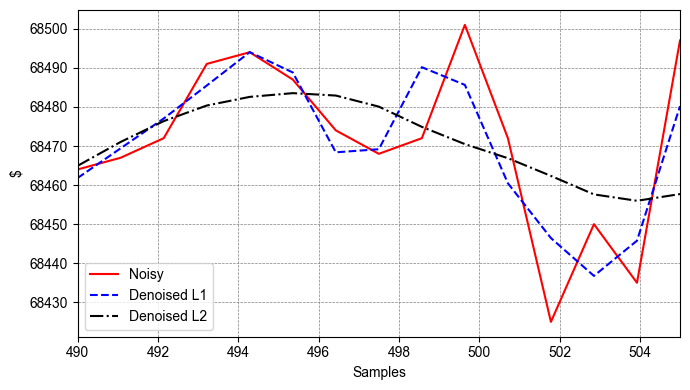

In [23]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Helvetica']

a = 490
b = 505

t = np.linspace(a, b, b-a)
signal1 = close[a:b]
signal2 = denoised_data_1[a:b]
signal3 = denoised_data_2[a:b]

fig, ax = plt.subplots(1,1, figsize=(7,4))
ax.plot(t, signal1, color = 'red', label = 'Noisy')
ax.plot(t, signal2, 'b--', label= 'Denoised L1')
ax.plot(t, signal3, color='black', linestyle='-.',  label = 'Denoised L2')
ax.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
ax.set_xlabel('Samples')
ax.set_ylabel('$')
ax.set_xlim((a,b))
ax.legend()

plt.tight_layout()
plt.savefig(f'denoise/img/noisy_denoised_L1_L2_{STOCK}_L2.png', dpi=300, bbox_inches='tight')
plt.show()

